# Notebook 2: Data Preprocessing & Feature Engineering

## Stock Price Forecasting Application

---

**Objective:** Clean the raw stock data, handle missing values, engineer technical indicator features, and prepare train/test splits for model training.

**Focus Stock:** AAPL (Apple Inc.) — used as the primary stock for feature engineering and modeling.

**Key Steps:**
1. Load raw data from Notebook 01
2. Handle missing values and inconsistencies
3. Engineer technical indicator features
4. Perform time-based train/test split
5. Scale features for model consumption
6. Save preprocessed datasets

## 2.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries imported successfully.')

Libraries imported successfully.


## 2.2 Load Raw Data

In [3]:
# Load AAPL raw data
data_dir = os.path.join('..', 'data')
df = pd.read_csv(os.path.join(data_dir, 'AAPL_raw.csv'), index_col='Date', parse_dates=True)

# Drop the Ticker column — we know this is AAPL
if 'Ticker' in df.columns:
    df = df.drop(columns=['Ticker'])

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (2516, 5)
Date range: 2015-01-02 to 2024-12-31

Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.2149,24.6822,23.7764,24.6712,212818400
2015-01-05,23.5327,24.0643,23.3467,23.9846,257142000
2015-01-06,23.5349,23.7941,23.1739,23.5970,263188400
2015-01-07,23.8649,23.9646,23.6324,23.7431,160423600
2015-01-08,24.7819,24.8395,24.0754,24.1927,237458000


## 2.3 Data Cleaning

### 2.3.1 Missing Value Assessment

In [4]:
# Check for missing values
missing_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(4)
})
print('Missing Value Report:')
display(missing_report)

# Check for duplicate indices (duplicate dates)
duplicates = df.index.duplicated().sum()
print(f'\nDuplicate date entries: {duplicates}')

Missing Value Report:


,Missing Count,Missing %
Close,0,0.0000
High,0,0.0000
Low,0,0.0000
Open,0,0.0000
Volume,0,0.0000



Duplicate date entries: 0


### 2.3.2 Handle Missing Values

For time-series data, forward-fill is the preferred method as it uses the most recent known value, which is more appropriate than interpolation or mean imputation when dealing with financial data.

In [5]:
# Forward-fill any missing values, then backward-fill the very first rows if needed
df = df.ffill().bfill()

# Remove any rows that might still have NaN (edge cases)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)
print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning: {rows_after}')
print(f'Rows removed: {rows_before - rows_after}')

# Verify no missing values remain
assert df.isnull().sum().sum() == 0, 'There are still missing values!'
print('\nAll missing values handled. Dataset is clean.')

Rows before cleaning: 2516
Rows after cleaning: 2516
Rows removed: 0

All missing values handled. Dataset is clean.


### 2.3.3 Data Type Verification and Consistency Checks

In [6]:
# Verify data types
print('Data Types:')
print(df.dtypes)

# Ensure all price columns are numeric
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Consistency checks: High >= Low, High >= Open/Close, etc.
invalid_hl = (df['High'] < df['Low']).sum()
invalid_prices = (df[['Open', 'High', 'Low', 'Close']] < 0).any().any()
invalid_volume = (df['Volume'] < 0).sum()

print(f'\nConsistency Checks:')
print(f'  High < Low violations: {invalid_hl}')
print(f'  Negative prices: {invalid_prices}')
print(f'  Negative volume: {invalid_volume}')

# Sort by date to ensure temporal order
df = df.sort_index()
print('\nData sorted by date. All checks passed.')

Data Types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Consistency Checks:
  High < Low violations: 0
  Negative prices: False
  Negative volume: 0

Data sorted by date. All checks passed.


## 2.4 Feature Engineering

We create technical indicator features commonly used in financial analysis and trading. These features capture momentum, trend, volatility, and historical patterns.

### 2.4.1 Moving Averages (Trend Indicators)

In [7]:
# Simple Moving Averages (SMA)
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Exponential Moving Averages (EMA)
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

print('Moving averages computed: SMA_10, SMA_20, SMA_50, EMA_10, EMA_20')

Moving averages computed: SMA_10, SMA_20, SMA_50, EMA_10, EMA_20


### 2.4.2 RSI — Relative Strength Index (Momentum)

In [8]:
def compute_rsi(series, window=14):
    """Compute Relative Strength Index."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = compute_rsi(df['Close'])
print('RSI computed (14-day window).')

RSI computed (14-day window).


### 2.4.3 MACD — Moving Average Convergence Divergence

In [9]:
# MACD
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

print('MACD, MACD Signal, and MACD Histogram computed.')

MACD, MACD Signal, and MACD Histogram computed.


### 2.4.4 Bollinger Bands (Volatility)

In [10]:
# Bollinger Bands (20-day, 2 standard deviations)
bb_window = 20
rolling_mean = df['Close'].rolling(window=bb_window).mean()
rolling_std = df['Close'].rolling(window=bb_window).std()

df['BB_Upper'] = rolling_mean + (2 * rolling_std)
df['BB_Lower'] = rolling_mean - (2 * rolling_std)
df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']

print('Bollinger Bands computed (20-day, 2σ).')

Bollinger Bands computed (20-day, 2σ).


### 2.4.5 Average True Range (ATR)

In [11]:
# Average True Range (14-day)
high_low = df['High'] - df['Low']
high_close = (df['High'] - df['Close'].shift()).abs()
low_close = (df['Low'] - df['Close'].shift()).abs()
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR'] = true_range.rolling(window=14).mean()

print('Average True Range (ATR) computed (14-day).')

Average True Range (ATR) computed (14-day).


### 2.4.6 Lag Features and Returns

In [12]:
# Lag features (previous day prices)
df['Close_Lag1'] = df['Close'].shift(1)
df['Close_Lag3'] = df['Close'].shift(3)
df['Close_Lag5'] = df['Close'].shift(5)

# Daily return
df['Daily_Return'] = df['Close'].pct_change()

# Rolling volatility (20-day annualized)
df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std() * np.sqrt(252)

# Price change features
df['High_Low_Pct'] = (df['High'] - df['Low']) / df['Low']
df['Open_Close_Pct'] = (df['Close'] - df['Open']) / df['Open']

print('Lag features, returns, and volatility computed.')

Lag features, returns, and volatility computed.


### 2.4.7 Target Variable

Our target is the **next day's closing price**. This is a regression target — we shift the closing price by -1 to align today's features with tomorrow's price.

In [13]:
# Target: Next day's closing price
df['Target'] = df['Close'].shift(-1)

print('Target variable created: next-day closing price.')
print(f'\nDataset shape after feature engineering: {df.shape}')
print(f'\nAll features:')
print(list(df.columns))

Target variable created: next-day closing price.

Dataset shape after feature engineering: (2516, 26)

All features:
['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_10', 'EMA_20', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Lower', 'BB_Width', 'ATR', 'Close_Lag1', 'Close_Lag3', 'Close_Lag5', 'Daily_Return', 'Volatility_20', 'High_Low_Pct', 'Open_Close_Pct', 'Target']


## 2.5 Remove NaN Rows from Feature Engineering

Rolling window calculations create NaN values at the beginning of the dataset. We need to drop these rows to ensure a complete dataset.

In [14]:
# Check NaN counts per column
nan_report = df.isnull().sum()
print('NaN values per column (from rolling window calculations):\n')
print(nan_report[nan_report > 0])

# Drop all rows with NaN values
rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f'\nRows before dropping NaNs: {rows_before}')
print(f'Rows after dropping NaNs: {rows_after}')
print(f'Rows dropped: {rows_before - rows_after}')
print(f'\nFinal dataset shape: {df.shape}')

NaN values per column (from rolling window calculations):

SMA_10            9
SMA_20           19
SMA_50           49
RSI              14
BB_Upper         19
BB_Lower         19
BB_Width         19
ATR              13
Close_Lag1        1
Close_Lag3        3
Close_Lag5        5
Daily_Return      1
Volatility_20    20
Target            1
dtype: int64

Rows before dropping NaNs: 2516
Rows after dropping NaNs: 2466
Rows dropped: 50

Final dataset shape: (2466, 26)


## 2.6 Visualize Engineered Features

In [15]:
# Plot price with moving averages
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=('Price & Moving Averages', 'RSI', 'MACD'),
                    row_heights=[0.5, 0.25, 0.25])

# Price and MAs
fig.add_trace(go.Scatter(x=df.index, y=df['Close'], name='Close', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['SMA_20'], name='SMA 20', line=dict(color='orange', dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['SMA_50'], name='SMA 50', line=dict(color='red', dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['BB_Upper'], name='BB Upper', line=dict(color='gray', dash='dot')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['BB_Lower'], name='BB Lower', line=dict(color='gray', dash='dot')), row=1, col=1)

# RSI
fig.add_trace(go.Scatter(x=df.index, y=df['RSI'], name='RSI', line=dict(color='purple')), row=2, col=1)
fig.add_hline(y=70, line_dash='dash', line_color='red', row=2, col=1)
fig.add_hline(y=30, line_dash='dash', line_color='green', row=2, col=1)

# MACD
fig.add_trace(go.Scatter(x=df.index, y=df['MACD'], name='MACD', line=dict(color='blue')), row=3, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['MACD_Signal'], name='Signal', line=dict(color='red')), row=3, col=1)
fig.add_trace(go.Bar(x=df.index, y=df['MACD_Hist'], name='Histogram', marker_color='gray'), row=3, col=1)

fig.update_layout(height=900, title='AAPL — Technical Indicators Overview', template='plotly_white')
fig.show()

## 2.7 Feature Correlation Analysis

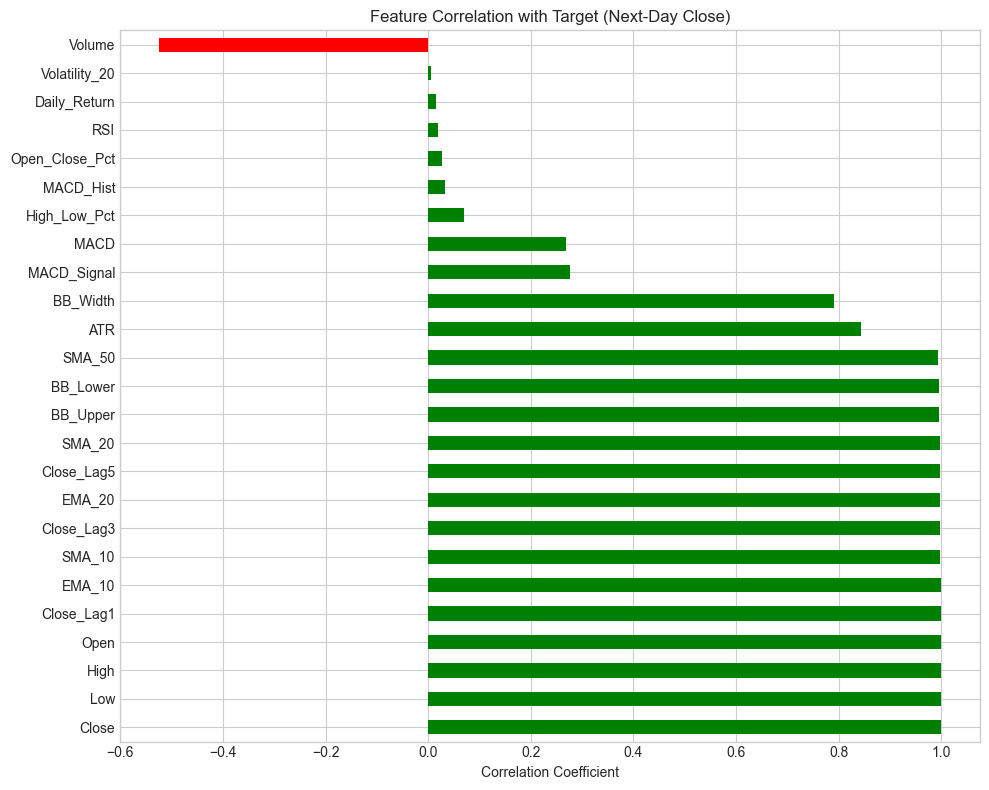


Top 10 features most correlated with target:


,Correlation
Close,0.9996
Low,0.9994
High,0.9994
Open,0.9993
Close_Lag1,0.9991
EMA_10,0.9988
SMA_10,0.9984
Close_Lag3,0.9984
EMA_20,0.9978
Close_Lag5,0.9976


In [16]:
# Correlation of all features with the target
feature_cols = [col for col in df.columns if col not in ['Target', 'Adj Close']]
corr_with_target = df[feature_cols + ['Target']].corr()['Target'].drop('Target').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_with_target.plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_with_target])
plt.title('Feature Correlation with Target (Next-Day Close)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print('\nTop 10 features most correlated with target:')
display(corr_with_target.head(10).to_frame('Correlation'))

## 2.8 Train/Test Split

For time-series data, we use a **chronological split** rather than random splitting to prevent data leakage. The training set consists of the earlier 80% of the data, and the test set is the most recent 20%.

This preserves the temporal ordering and simulates a realistic forecasting scenario.

In [17]:
# Define feature columns (exclude target and Adj Close)
feature_columns = [col for col in df.columns if col not in ['Target', 'Adj Close']]

X = df[feature_columns]
y = df['Target']

# Time-based split: 80% train, 20% test
split_idx = int(len(df) * 0.8)
split_date = df.index[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Split date: {split_date.date()}')
print(f'\nTraining set: {X_train.shape[0]} samples ({X_train.index.min().date()} to {X_train.index.max().date()})')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.index.min().date()} to {X_test.index.max().date()})')
print(f'\nFeatures: {X_train.shape[1]}')
print(f'Train/Test ratio: {X_train.shape[0]/len(X):.1%} / {X_test.shape[0]/len(X):.1%}')

Split date: 2023-01-12

Training set: 1972 samples (2015-03-16 to 2023-01-11)
Test set:     494 samples (2023-01-12 to 2024-12-30)

Features: 25
Train/Test ratio: 80.0% / 20.0%


In [20]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=X_train.index, y=y_train, mode='lines', name='Training Data', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=X_test.index, y=y_test, mode='lines', name='Test Data', line=dict(color='red')))

# Add vertical line at split date using add_shape to avoid Plotly annotation bug
fig.add_shape(type='line', x0=split_date, x1=split_date, y0=0, y1=1, yref='paper',
              line=dict(color='black', dash='dash', width=2))
fig.add_annotation(x=split_date, y=1, yref='paper', text='Train/Test Split',
                   showarrow=False, yanchor='bottom', font=dict(size=12))

fig.update_layout(
    title='AAPL — Train/Test Split Visualization',
    xaxis_title='Date',
    yaxis_title='Close Price ($)',
    template='plotly_white',
    height=400
)
fig.show()

## 2.9 Feature Scaling

We apply `StandardScaler` to normalize features. This is essential for models sensitive to feature scale (Linear Regression, LSTM). Tree-based models (Random Forest, XGBoost) are scale-invariant but we scale uniformly for consistency.

**Important:** The scaler is fit on the training data only to prevent information leakage from the test set.

In [21]:
# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Feature scaling complete (StandardScaler).')
print(f'\nScaled training data — mean (should be ~0): {X_train_scaled.mean().mean():.6f}')
print(f'Scaled training data — std  (should be ~1): {X_train_scaled.std().mean():.6f}')

X_train_scaled.describe().T.head(10)

Feature scaling complete (StandardScaler).

Scaled training data — mean (should be ~0): -0.000000
Scaled training data — std  (should be ~1): 1.000254


,count,mean,std,min,25%,50%,75%,max
Close,1972.0000,0.0000,1.0003,-1.0436,-0.8160,-0.4921,1.0370,2.1816
High,1972.0000,-0.0000,1.0003,-1.0400,-0.8196,-0.4956,1.0307,2.1565
Low,1972.0000,0.0000,1.0003,-1.0447,-0.8121,-0.4942,1.0410,2.1707
Open,1972.0000,0.0000,1.0003,-1.0447,-0.8143,-0.4940,1.0356,2.1958
Volume,1972.0000,-0.0000,1.0003,-1.4385,-0.6638,-0.2774,0.3570,7.9963
SMA_10,1972.0000,-0.0000,1.0003,-1.0297,-0.8169,-0.4938,1.0434,2.1158
SMA_20,1972.0000,-0.0000,1.0003,-1.0206,-0.8295,-0.4985,1.0355,2.0856
SMA_50,1972.0000,-0.0000,1.0003,-1.0018,-0.8602,-0.4930,1.0927,2.0435
EMA_10,1972.0000,-0.0000,1.0003,-1.0273,-0.8201,-0.4969,1.0437,2.1116
EMA_20,1972.0000,0.0000,1.0003,-1.0133,-0.8310,-0.5006,1.0451,2.0568


## 2.10 Save Preprocessed Data

Save the preprocessed train/test data and scaler for use in modeling notebooks.

In [22]:
import joblib

# Save the full preprocessed DataFrame
df.to_csv(os.path.join(data_dir, 'AAPL_preprocessed.csv'))

# Save train/test splits (unscaled — models that don't need scaling can use these)
X_train.to_csv(os.path.join(data_dir, 'X_train.csv'))
X_test.to_csv(os.path.join(data_dir, 'X_test.csv'))
y_train.to_csv(os.path.join(data_dir, 'y_train.csv'))
y_test.to_csv(os.path.join(data_dir, 'y_test.csv'))

# Save scaled train/test splits
X_train_scaled.to_csv(os.path.join(data_dir, 'X_train_scaled.csv'))
X_test_scaled.to_csv(os.path.join(data_dir, 'X_test_scaled.csv'))

# Save the scaler
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)
joblib.dump(scaler, os.path.join(models_dir, 'feature_scaler.pkl'))

# Save feature column names for later reference
pd.Series(feature_columns).to_csv(os.path.join(data_dir, 'feature_columns.csv'), index=False)

print('All preprocessed data saved successfully!')
print(f'\nFiles saved in {os.path.abspath(data_dir)}:')
for f in os.listdir(data_dir):
    size_kb = os.path.getsize(os.path.join(data_dir, f)) / 1024
    print(f'  {f} ({size_kb:.1f} KB)')

All preprocessed data saved successfully!

Files saved in c:\Learning\Python\AIML-Capstone-Project\data:
  AAPL_preprocessed.csv (1191.4 KB)
  AAPL_raw.csv (246.7 KB)
  all_stocks_raw.csv (1217.5 KB)
  AMZN_raw.csv (237.8 KB)
  feature_columns.csv (0.2 KB)
  GOOGL_raw.csv (246.7 KB)
  MSFT_raw.csv (244.0 KB)
  TSLA_raw.csv (242.5 KB)
  X_test.csv (230.3 KB)
  X_test_scaled.csv (235.0 KB)
  X_train.csv (917.3 KB)
  X_train_scaled.csv (970.7 KB)
  y_test.csv (14.7 KB)
  y_train.csv (58.4 KB)


## 2.11 Preprocessing Summary

| Step | Action | Details |
|------|--------|---------|
| Missing Values | Forward-fill + backward-fill | Preserves temporal continuity |
| Data Types | Verified numeric columns | All OHLCV columns confirmed numeric |
| Consistency | Checked High >= Low, no negatives | All checks passed |
| Feature Engineering | Created 20+ technical indicators | SMA, EMA, RSI, MACD, Bollinger Bands, ATR, lags, returns |
| Target Variable | Next-day closing price (shift -1) | Regression target |
| Train/Test Split | 80/20 chronological split | No data leakage |
| Scaling | StandardScaler (fit on train only) | Zero mean, unit variance |

---

**Next Step:** Proceed to Notebook 03 — Modeling, where we will train Linear Regression, Random Forest, XGBoost, and LSTM models on this preprocessed data.